In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
# stratifiedKFold is a cross-validation technique that ensures that each fold of the dataset has a representative distribution of the target variable. It is particularly useful when dealing with imbalanced datasets, as it helps to maintain the proportion of classes in each fold, leading to more reliable and robust model evaluation.
#GridSearchCV is used to find the best hyperparameters for a model by exhaustively searching through a specified parameter grid. It performs cross-validation to evaluate the performance of each combination of hyperparameters and selects the one that yields the best results based on a specified scoring metric.
from sklearn.pipeline import Pipeline
#Pipeline is a tool in scikit-learn that allows you to chain together multiple steps of a machine learning workflow, such as data preprocessing and model training, into a single object. This helps to streamline the process and ensures that the same transformations are applied consistently during both training and testing phases.
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
#LogisticRegression is a statistical model used for binary classification tasks. It estimates the probability that a given input belongs to a particular class by fitting a logistic function to the data. The model is trained using maximum likelihood estimation, and it can be used to predict the class labels for new, unseen data based on the learned relationships between the features and the target variable.
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC


In [3]:
#configuration

pd.set_option('display.max_columns', None)
#show all columns in the dataframe when printed
pd.set_option('display.float_format', lambda x: '%.3f' % x)
#format floating-point numbers to three decimal places when displayed
pd.set_option('display.max_rows', None)
#show all rows in the dataframe when printed
sns.set_theme(style="darkgrid")
#sets the theme for seaborn plots to "darkgrid", which provides a dark background with gridlines for better visualization of data. 


In [4]:
# loading the data
df=pd.read_csv('../Breast-Cancer-Diagnosis-Analysis/Data Set/Breast Cancer.csv')
df.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,NaN
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,NaN


In [5]:
df.shape

(569, 33)

### EDA

In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [7]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [8]:
#dropping the id and unnamed:32 columns as they are not useful for analysis
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#check if there is any encoding missing values - top  repeating values in the dataset
for col in df.columns:
    print(f"Top 5 repeating values in column '{col}':")
    print(df[col].value_counts().head(10))
    print("\n")

Top 5 repeating values in column 'diagnosis':
diagnosis
B    357
M    212
Name: count, dtype: int64


Top 5 repeating values in column 'radius_mean':
radius_mean
12.340    4
11.060    3
10.260    3
12.770    3
13.050    3
13.850    3
12.180    3
11.600    3
13.000    3
11.710    3
Name: count, dtype: int64


Top 5 repeating values in column 'texture_mean':
texture_mean
16.840    3
19.830    3
15.700    3
20.520    3
18.220    3
14.930    3
18.900    3
17.460    3
16.850    3
20.130    2
Name: count, dtype: int64


Top 5 repeating values in column 'perimeter_mean':
perimeter_mean
82.610     3
134.700    3
87.760     3
129.100    2
82.690     2
132.900    2
130.000    2
81.350     2
94.250     2
58.790     2
Name: count, dtype: int64


Top 5 repeating values in column 'area_mean':
area_mean
512.200     3
394.100     2
399.800     2
1076.000    2
582.700     2
334.200     2
1075.000    2
561.000     2
716.600     2
466.100     2
Name: count, dtype: int64


Top 5 repeating values in column

In [12]:
# identyfy the class imbalance
df['diagnosis'].value_counts(normalize=True)*100

diagnosis
B   62.742
M   37.258
Name: proportion, dtype: float64

In [13]:
# map the target variable to binary values
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [14]:
# class distribution after mapping
df['diagnosis'].value_counts(normalize=True)*100

diagnosis
0   62.742
1   37.258
Name: proportion, dtype: float64

In [15]:
# grouping
df.groupby('diagnosis').mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026,0.174,0.063,0.284,1.220,2.000,21.135,0.007,0.021,0.026,0.010,0.021,0.004,13.380,23.515,87.006,558.899,0.125,0.183,0.166,0.074,0.270,0.079
1,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088,0.193,0.063,0.609,1.211,4.324,72.672,0.007,0.032,0.042,0.015,0.020,0.004,21.135,29.318,141.370,1422.286,0.145,0.375,0.451,0.182,0.323,0.092


### Data Visualization

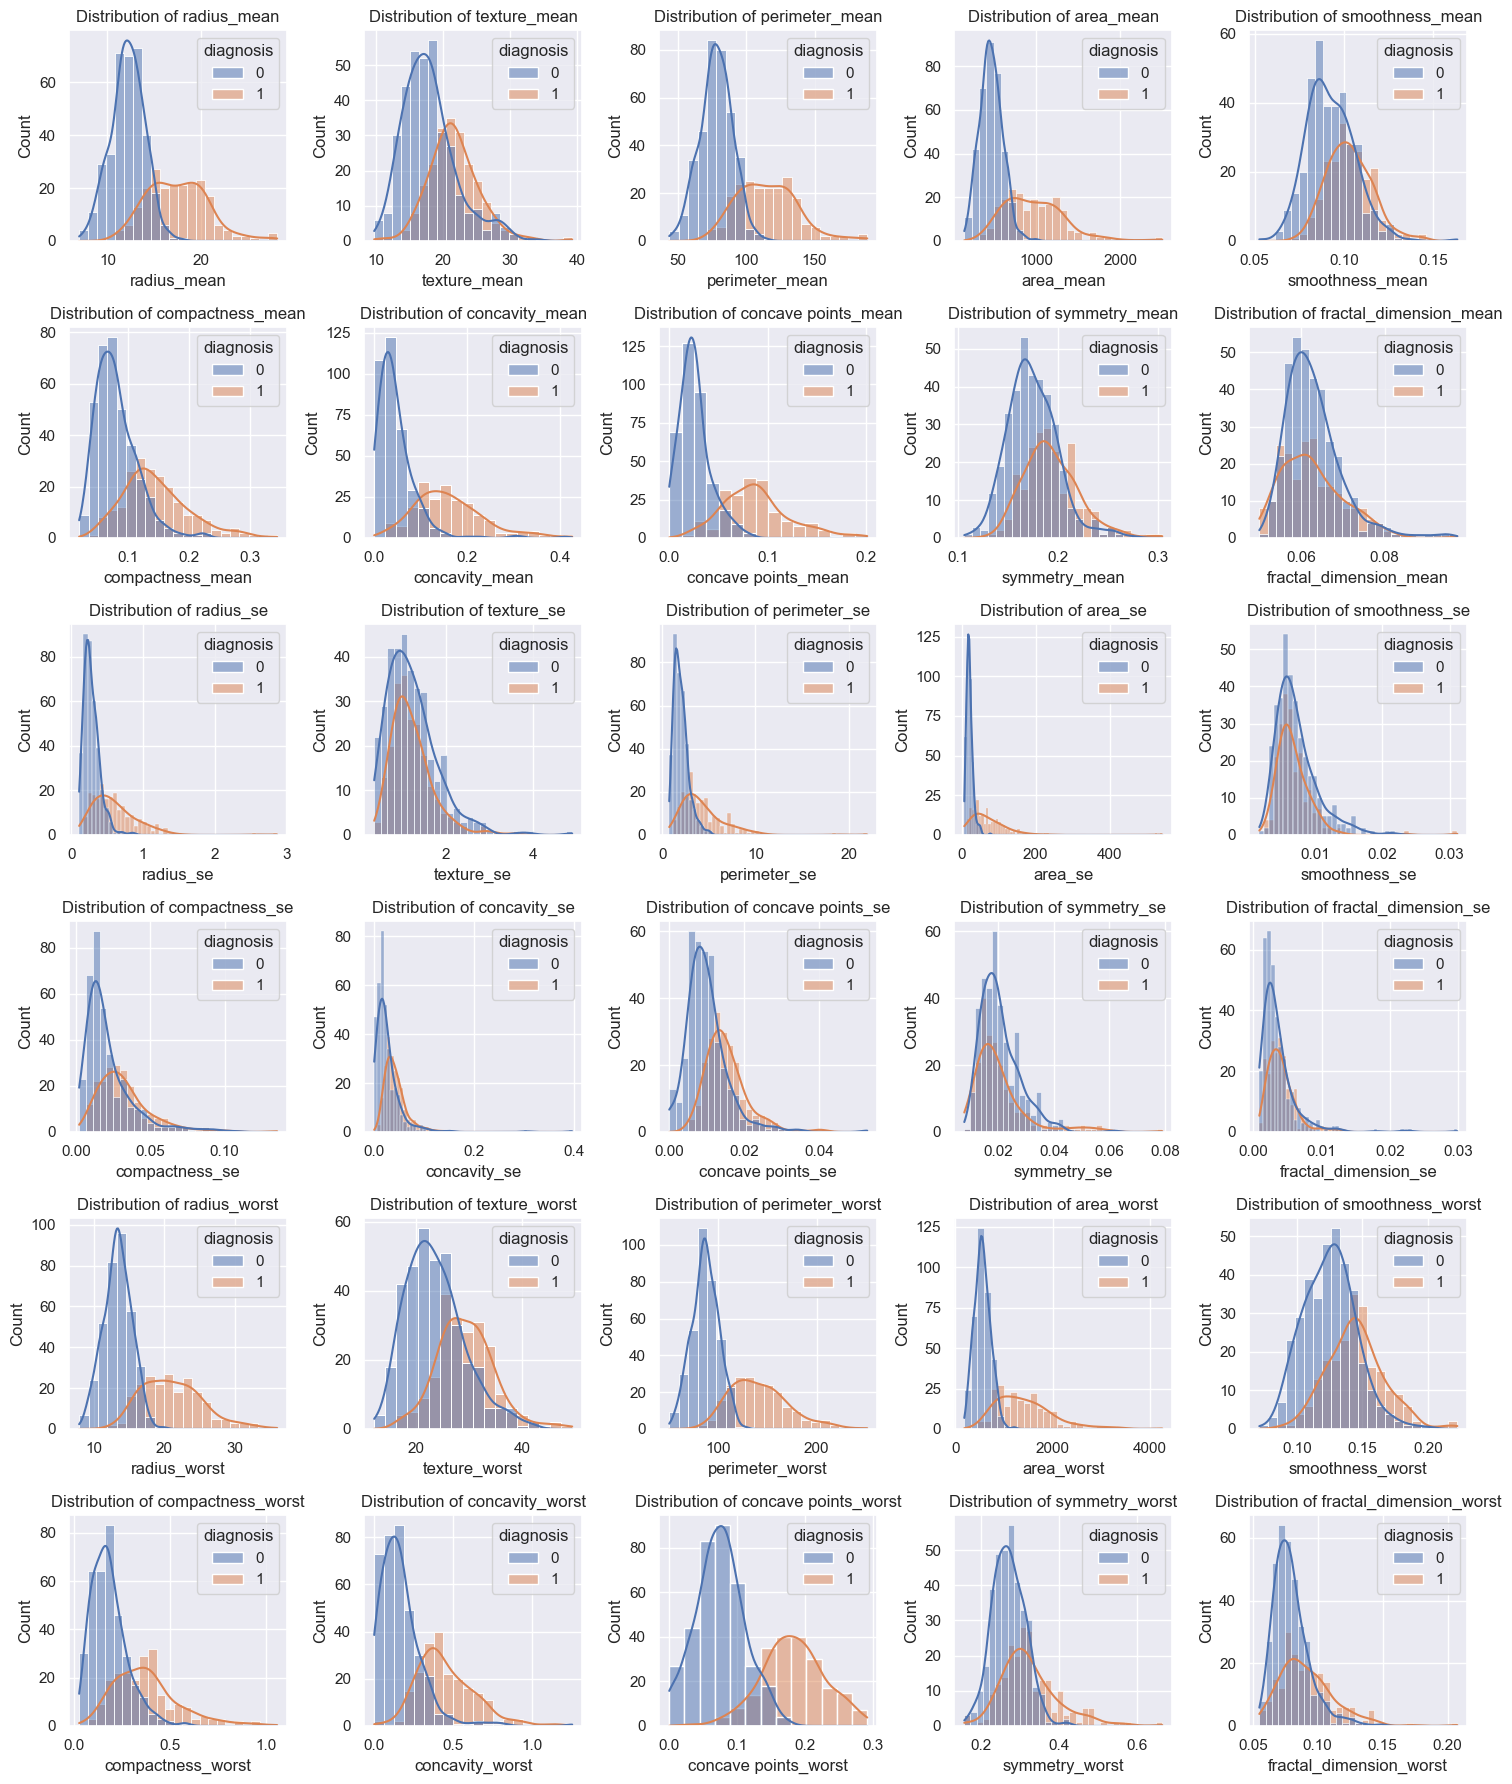

In [17]:
# histo plots for  distribution of features
fig ,axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):
    sns.histplot(data=df, x=col, hue='diagnosis', ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

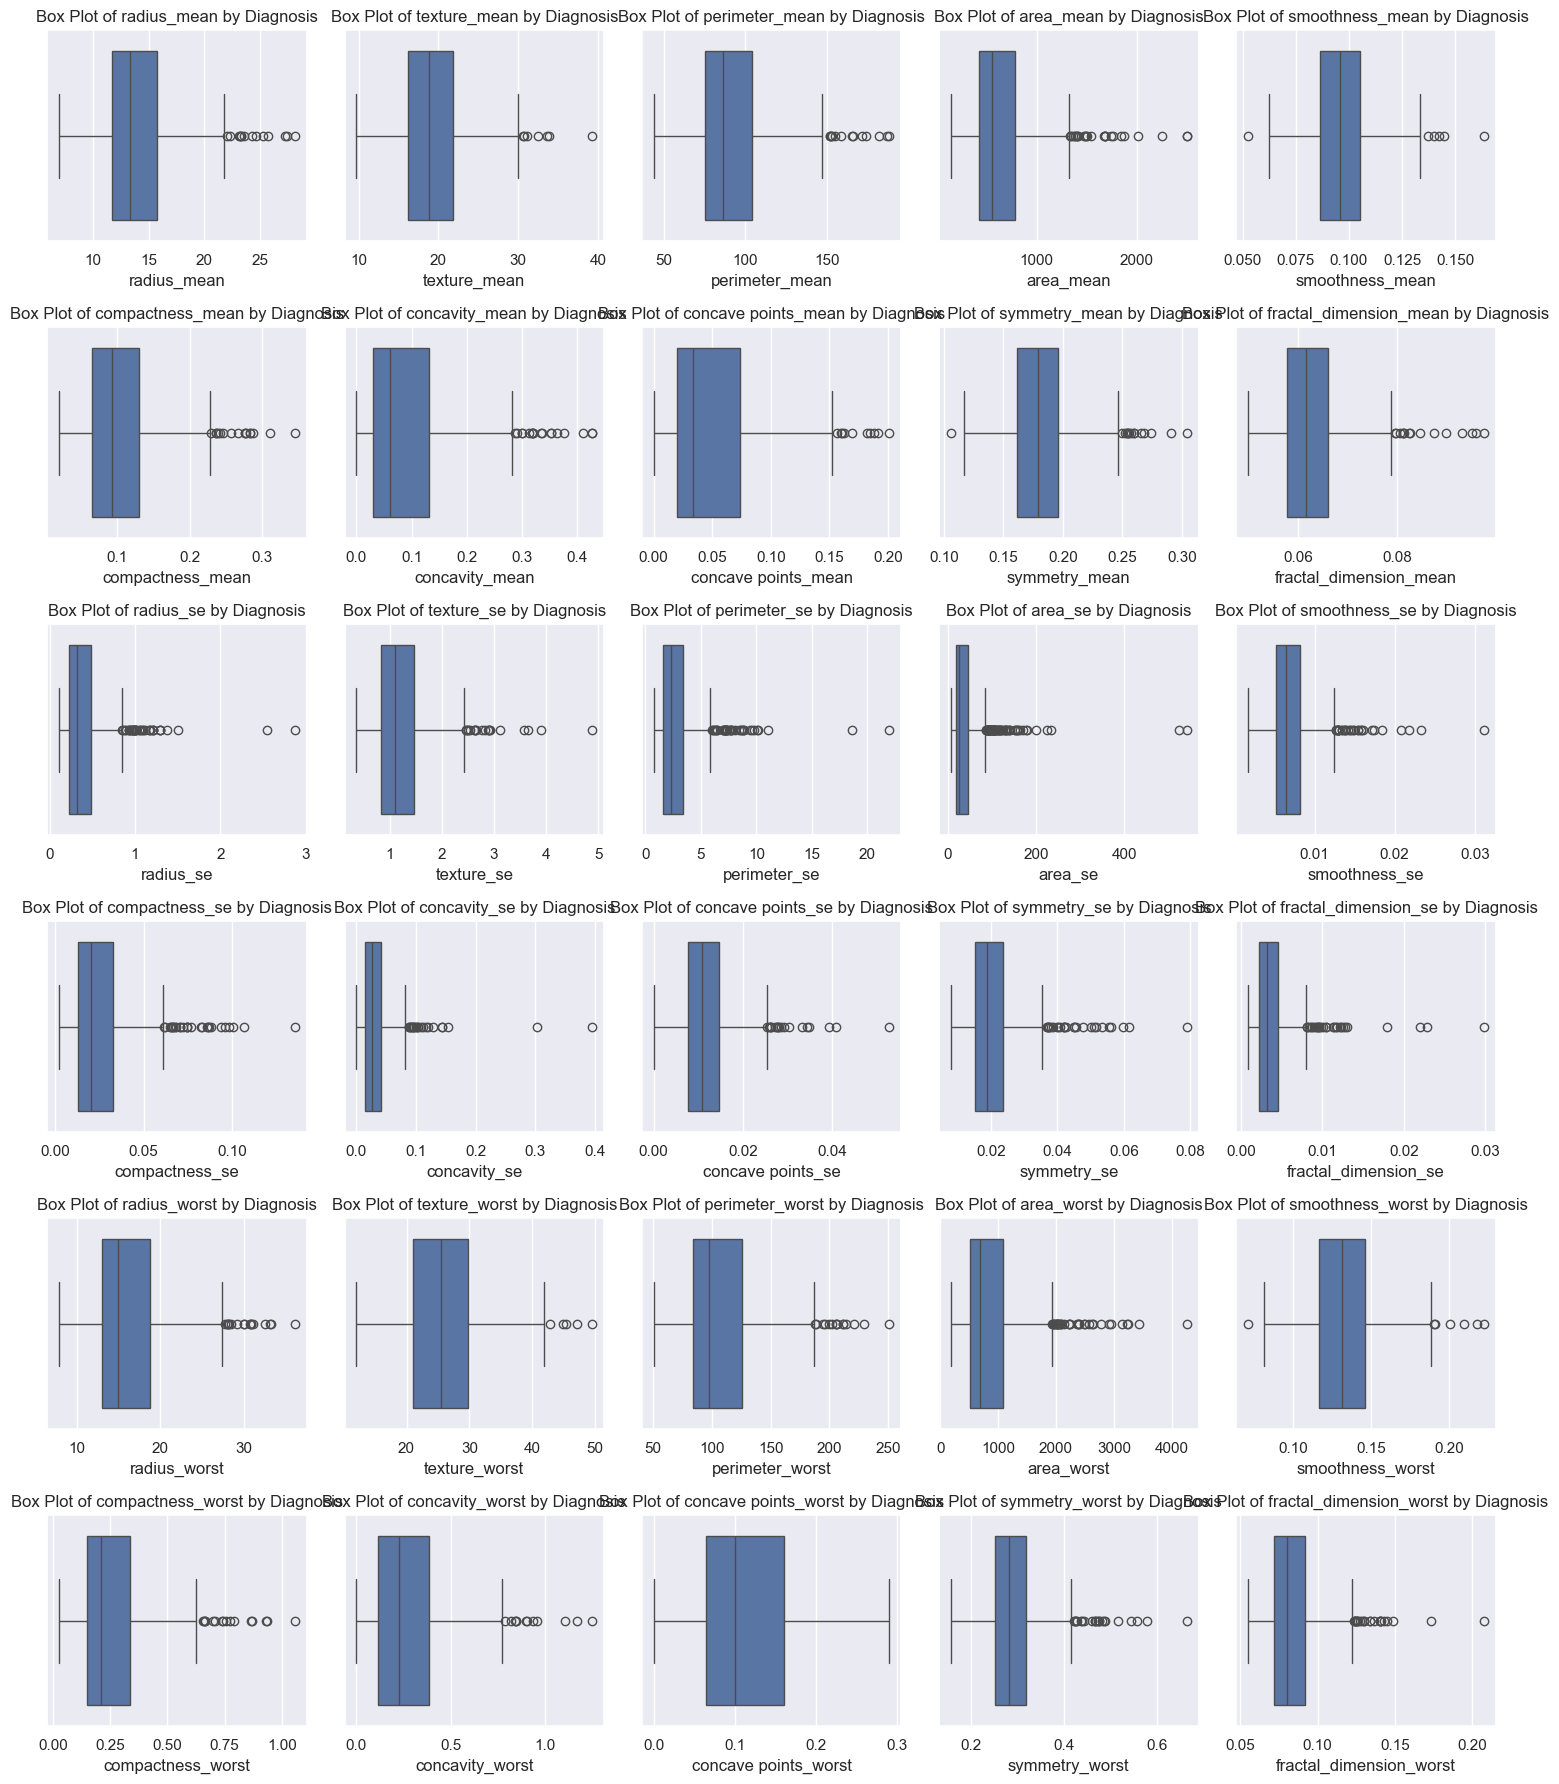

In [19]:
#box plots for distribution of features
fig ,axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col} by Diagnosis')
plt.tight_layout()
plt.show()

In [24]:
# display all rows and columns of the dataframe
pd.set_option('display.max_rows', None)

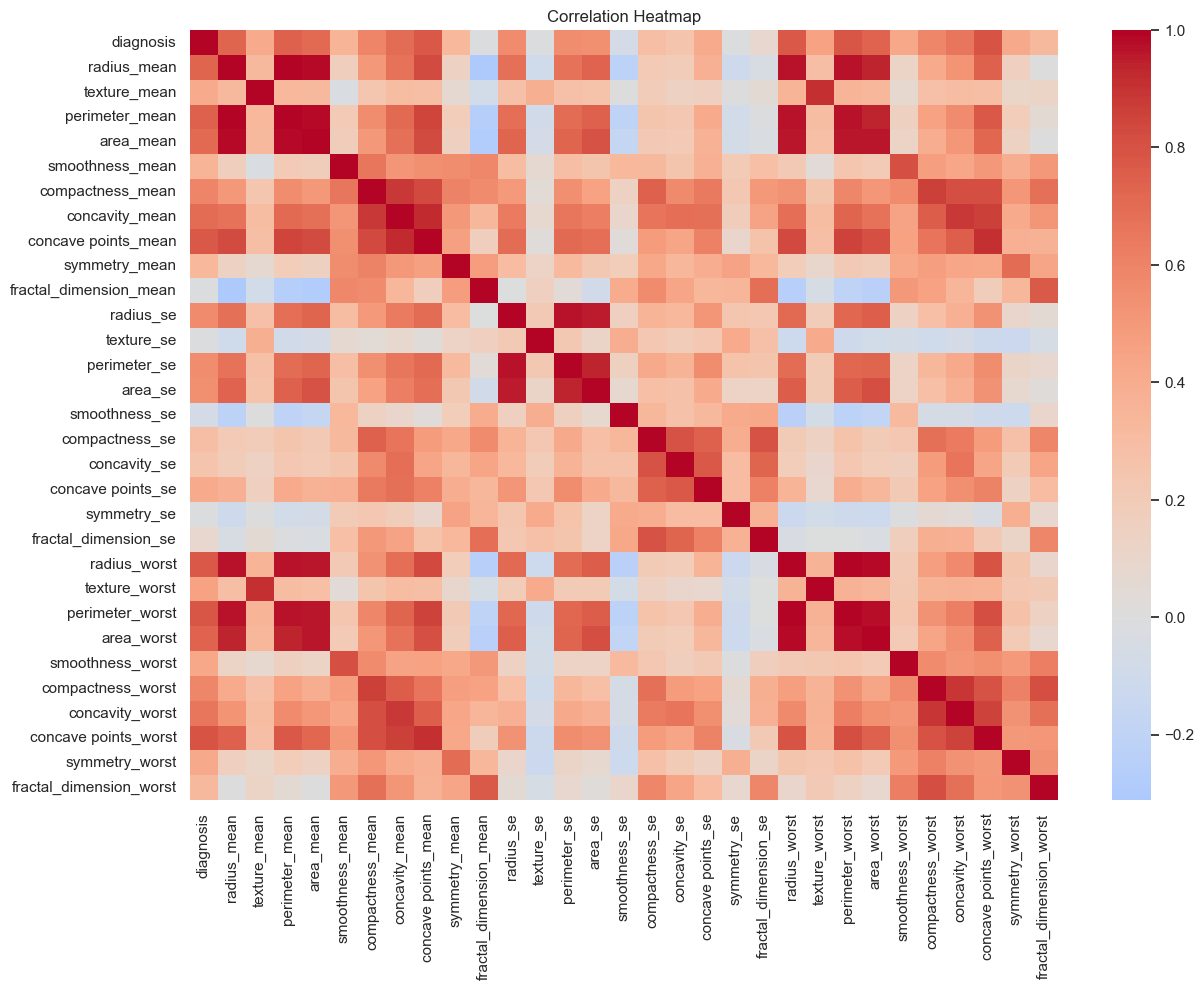

In [25]:
#heat map for correlation
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), center=0, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:

# get value range each feature
for col in df.columns[1:]:
    print(f"Value range for column '{col}': {df[col].min()} - {df[col].max()}")

Value range for column 'radius_mean': 6.981 - 28.11
Value range for column 'texture_mean': 9.71 - 39.28
Value range for column 'perimeter_mean': 43.79 - 188.5
Value range for column 'area_mean': 143.5 - 2501.0
Value range for column 'smoothness_mean': 0.05263 - 0.1634
Value range for column 'compactness_mean': 0.01938 - 0.3454
Value range for column 'concavity_mean': 0.0 - 0.4268
Value range for column 'concave points_mean': 0.0 - 0.2012
Value range for column 'symmetry_mean': 0.106 - 0.304
Value range for column 'fractal_dimension_mean': 0.04996 - 0.09744
Value range for column 'radius_se': 0.1115 - 2.873
Value range for column 'texture_se': 0.3602 - 4.885
Value range for column 'perimeter_se': 0.757 - 21.98
Value range for column 'area_se': 6.802 - 542.2
Value range for column 'smoothness_se': 0.001713 - 0.03113
Value range for column 'compactness_se': 0.002252 - 0.1354
Value range for column 'concavity_se': 0.0 - 0.396
Value range for column 'concave points_se': 0.0 - 0.05279
Value 

In [27]:
#identfy high correlation features
correlation_matrix = df.corr()
high_correlation = correlation_matrix[correlation_matrix > 0.8].stack().reset_index()
high_correlation = high_correlation[high_correlation['level_0'] != high_correlation['level_1']]
high_correlation.columns = ['Feature1', 'Feature2', 'Correlation']

print("Highly correlated features (correlation > 0.8):")
print(high_correlation)



Highly correlated features (correlation > 0.8):
                    Feature1                 Feature2  Correlation
2                radius_mean           perimeter_mean        0.998
3                radius_mean                area_mean        0.987
4                radius_mean      concave points_mean        0.823
5                radius_mean             radius_worst        0.970
6                radius_mean          perimeter_worst        0.965
7                radius_mean               area_worst        0.941
9               texture_mean            texture_worst        0.912
10            perimeter_mean              radius_mean        0.998
12            perimeter_mean                area_mean        0.987
13            perimeter_mean      concave points_mean        0.851
14            perimeter_mean             radius_worst        0.969
15            perimeter_mean          perimeter_worst        0.970
16            perimeter_mean               area_worst        0.942
17            

### Data  

In [ ]:
# separete features and target variable
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [29]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Logistic Regression 

In [30]:
  # scale the features
scaler = StandardScaler()


In [31]:

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [32]:
# model training and evaluation
model = LogisticRegression()

In [33]:
model.fit(x_train_scaled, y_train)

LogisticRegression()

In [34]:
# traing accuracy
model.score(x_train_scaled, y_train) 

0.9868131868131869

In [35]:
#evaluate the  model test accuracy
model.score(x_test_scaled, y_test)  

0.9649122807017544

### model optimization

In [39]:
#pipeline  creation
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('model',SVC(kernel='rbf'))
])



In [40]:
#grid search for hyperparameter tuning
param_grid = {
    'pca__n_components': [10,15, 20, 25, 30] ,
    'model__C': [0.1, 1, 10, 100, 1000],
    'model__gamma': [0.001,0.01, 0.1, 1, 'scale']
}

In [42]:
 # cross validation
k=5
skf=StratifiedKFold(n_splits=k, shuffle=True, random_state=42)



In [43]:
# hiperparameter tuning using grid search
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    scoring='recall',
    cv=skf, 
    n_jobs=-1, 
)

In [44]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()), ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 100, 1000],
                         'model__gamma': [0.001, 0.01, 0.1, 1, 'scale'],
                         'pca__n_components': [10, 15, 20, 25, 30]},
             scoring='recall')

In [45]:
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'model__C': 10, 'model__gamma': 'scale', 'pca__n_components': 10}


In [46]:
# best score
print("Best Recall Score:", grid_search.best_score_)


Best Recall Score: 0.9647058823529411


#### Train with best parameters

In [48]:
best_pipeline = Pipeline(
    [
        ('best_scaler', StandardScaler()),
        ('best_pca', PCA(n_components=grid_search.best_params_['pca__n_components'])),
        ('best_model', SVC(kernel='rbf', C=grid_search.best_params_['model__C'], gamma=grid_search.best_params_['model__gamma']))

    ]
)

In [49]:
 #train the best pipeline on the entire training data
best_pipeline.fit(x_train, y_train)

Pipeline(steps=[('best_scaler', StandardScaler()),
                ('best_pca', PCA(n_components=10)), ('best_model', SVC(C=10))])

#### model evaluation

In [50]:
y_train_pred = best_pipeline.predict(x_train)
y_test_pred = best_pipeline.predict(x_test) 

In [51]:
# traing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.989010989010989


In [56]:
# test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9649122807017544


In [54]:
# confusion matrix training data
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_train

array([[285,   0],
       [  5, 165]])

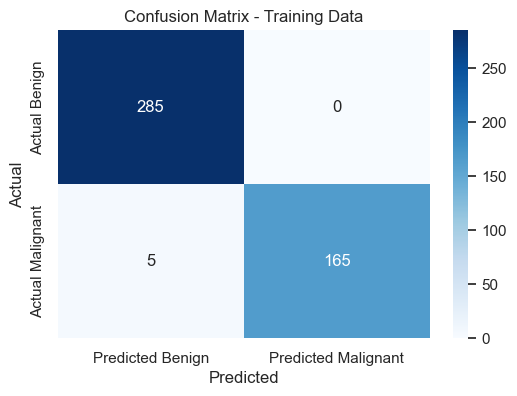

In [58]:
#heatmap for confusion matrix training data
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_train,
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Predicted Benign', 'Predicted Malignant'],
    yticklabels=['Actual Benign', 'Actual Malignant'])

plt.title('Confusion Matrix - Training Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() 

In [60]:
# classification report for training data
class_report_train = classification_report(y_train, y_train_pred)
print("Classification Report - Training Data:")
print(class_report_train)



Classification Report - Training Data:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.97      0.99       170

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455



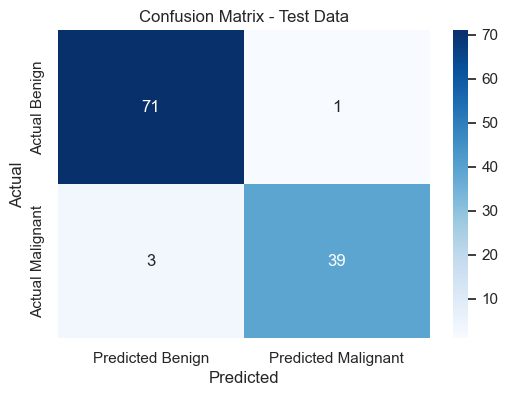

In [59]:
# confusion matrix
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
conf_matrix_test

#heatmap for confusion matrix test data
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_test,
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Predicted Benign', 'Predicted Malignant'],
    yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [61]:
# classification report for test data
class_report_test = classification_report(y_test, y_test_pred)
print("Classification Report - Test Data:")
print(class_report_test)

Classification Report - Test Data:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

